In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the 3 evaluation runs
#df1 = pd.read_csv("../eval_results/eval_20260504_121229_reduced.csv")
#df2 = pd.read_csv("../eval_results/eval_20260509_112934_reduced.csv")
#df3 = pd.read_csv("../eval_results/eval_20260509_123731_reduced_combined.csv")

#df1 = pd.read_csv("../eval_results/eval_20260510_112617_reduced.csv") # random seed
df1 = pd.read_csv("../eval_results/eval_20260510_125711_reduced.csv") # seed 42
df2 = pd.read_csv("../eval_results/eval_20260510_140530_reduced.csv") # seed 43
df3 = pd.read_csv("../eval_results/eval_20260516_122253_reduced.csv") # seed 44

runs = [df1, df2, df3]

numeric_cols = [
    "response_time",
    "faithfulness",
    "context_precision",
    "constraint_satisfaction",
    "hallucination_rate"
]

# Store grouped means from each run
run_results = []

for i, df in enumerate(runs, start=1):

    # Convert numeric columns
    df[numeric_cols] = df[numeric_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Mean per system for this run
    grouped_mean = (
        df.groupby("system")[numeric_cols]
        .mean()
    )

    grouped_mean["run"] = i

    run_results.append(grouped_mean.reset_index())

# Combine all runs
all_runs = pd.concat(run_results, ignore_index=True)

# Compute mean and stddev across runs
summary = (
    all_runs
    .groupby("system")[numeric_cols]
    .agg(["mean", "std"])
)

print(summary)

             response_time           faithfulness           context_precision  \
                      mean       std         mean       std              mean   
system                                                                          
llm               2.672941  0.450640          NaN       NaN               NaN   
rag_hybrid        3.009965  0.569891     0.880368  0.039730             0.470   
rag_standard      2.935542  0.570634     0.878920  0.005598             0.412   

                       constraint_satisfaction           hallucination_rate  \
                   std                    mean       std               mean   
system                                                                        
llm                NaN                0.989658  0.001743           0.027142   
rag_hybrid    0.020298                0.944000  0.018028                NaN   
rag_standard  0.020000                0.955260  0.010016                NaN   

                        
             

In [3]:
def analyze_seed(df):
    """Processes a single dataframe and returns better/equal/worse counts."""
    # 1. Grouping and Filtering
    df["group_id"] = df.index // 3
    subset = df[df["system"].isin(["rag_hybrid", "rag_standard"])]
    
    # 2. Pivot
    pivot = subset.pivot(index="group_id", columns="system", values=numeric_cols)
    hybrid = pivot.xs("rag_hybrid", level=1, axis=1)
    standard = pivot.xs("rag_standard", level=1, axis=1)
    
    # 3. Comparison Logic
    comparison = pd.DataFrame(index=hybrid.index, columns=hybrid.columns)
    
    higher_is_better = [col for col in numeric_cols if col not in ["response_time", "hallucination_rate"]]
    lower_is_better = ["response_time", "hallucination_rate"]
    
    comparison[higher_is_better] = (hybrid[higher_is_better] > standard[higher_is_better]).astype(int) - \
                                  (hybrid[higher_is_better] < standard[higher_is_better]).astype(int)
    
    comparison[lower_is_better] = (hybrid[lower_is_better] < standard[lower_is_better]).astype(int) - \
                                 (hybrid[lower_is_better] > standard[lower_is_better]).astype(int)
    
    # 4. Count Outcomes for this seed
    return (comparison == 1).sum(), (comparison == 0).sum(), (comparison == -1).sum()

# Execute analysis for all runs
results = [analyze_seed(run) for run in runs]

# Aggregate results (unpacking the tuples)
better_list, equal_list, worse_list = zip(*results)

# Calculate averages across all three seeds
avg_better = pd.concat(better_list, axis=1).mean(axis=1)
avg_equal = pd.concat(equal_list, axis=1).mean(axis=1)
avg_worse = pd.concat(worse_list, axis=1).mean(axis=1)

# Display final results
print("--- Average Outcomes Across 3 Seeds ---")
print("\nBetter:\n", avg_better)
print("\nEqual:\n", avg_equal)
print("\nWorse:\n", avg_worse)

--- Average Outcomes Across 3 Seeds ---

Better:
 response_time              45.666667
faithfulness               15.666667
context_precision          41.333333
constraint_satisfaction    11.000000
hallucination_rate          0.000000
dtype: float64

Equal:
 response_time                0.000000
faithfulness                65.000000
context_precision           33.333333
constraint_satisfaction     73.000000
hallucination_rate         100.000000
dtype: float64

Worse:
 response_time              54.333333
faithfulness               19.333333
context_precision          25.333333
constraint_satisfaction    16.000000
hallucination_rate          0.000000
dtype: float64


In [4]:
df1['seed'] = 42
df2['seed'] = 43
df3['seed'] = 44

# Combine them into one "Master" dataframe
all_data = pd.concat([df1, df2, df3], ignore_index=True)

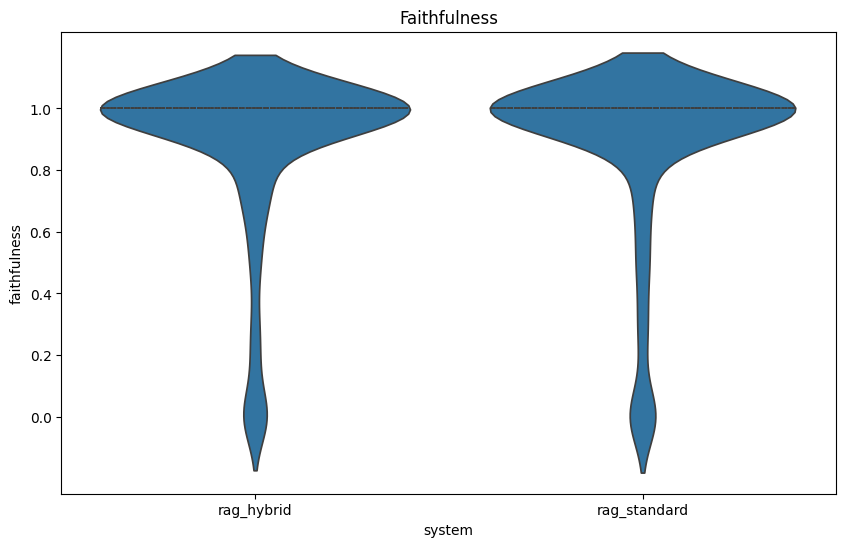

In [5]:
# Filter
plot_df = all_data[all_data["system"].isin(["rag_hybrid", "rag_standard"])]

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x="system", y="faithfulness", inner="quartile")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.title("Faithfulness")
plt.show()

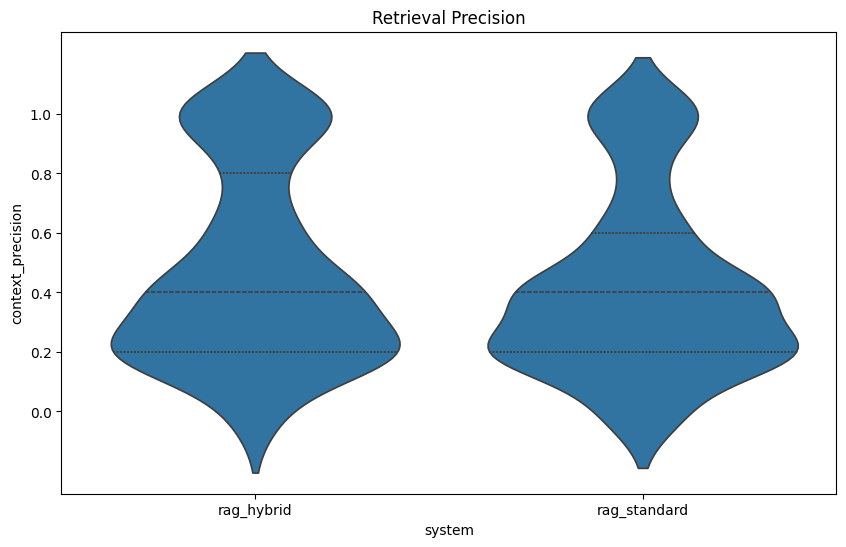

In [6]:
# Filter
plot_df = all_data[all_data["system"].isin(["rag_hybrid", "rag_standard"])]

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x="system", y="context_precision", inner="quartile")
plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.title("Retrieval Precision")
plt.show()

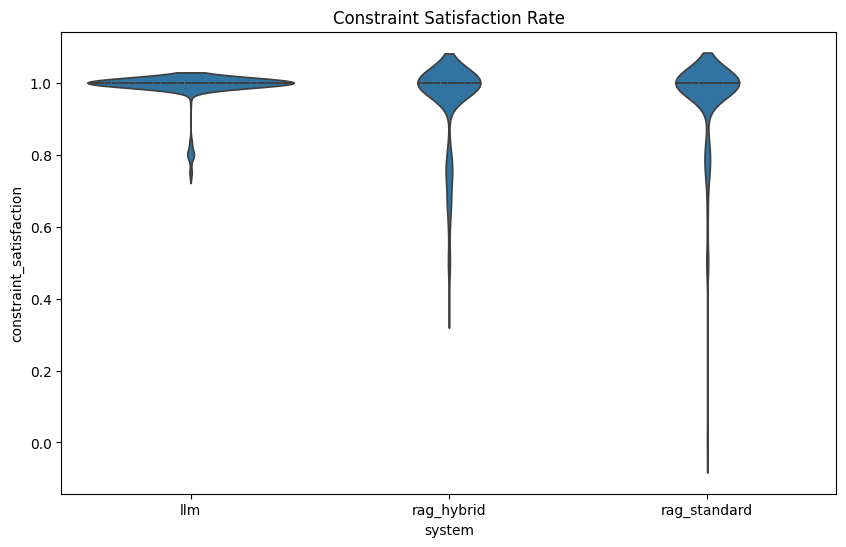

In [7]:
# Filter
plot_df = all_data[all_data["system"].isin(["llm", "rag_hybrid", "rag_standard"])]

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x="system", y="constraint_satisfaction", inner="quartile")
plt.title("Constraint Satisfaction Rate")
plt.show()

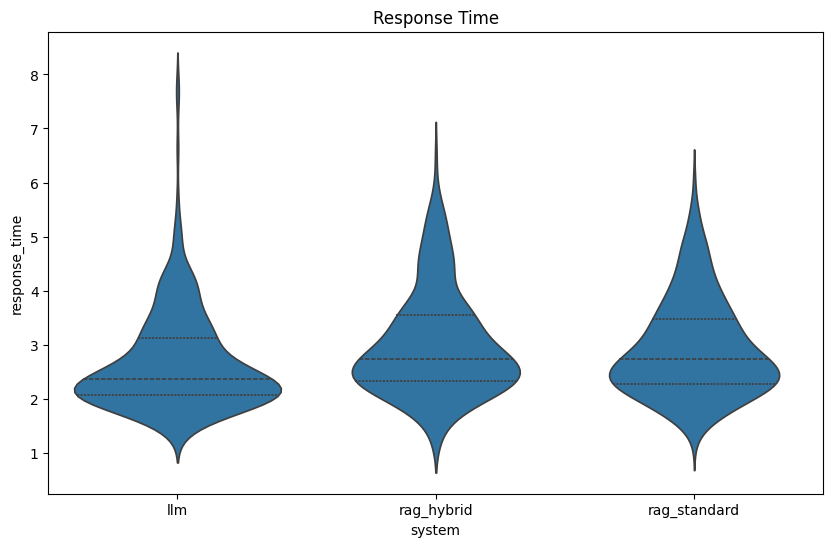

In [8]:
# Filter
plot_df = all_data[all_data["system"].isin(["llm", "rag_hybrid", "rag_standard"])]

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x="system", y="response_time", inner="quartile")
plt.title("Response Time")
plt.show()

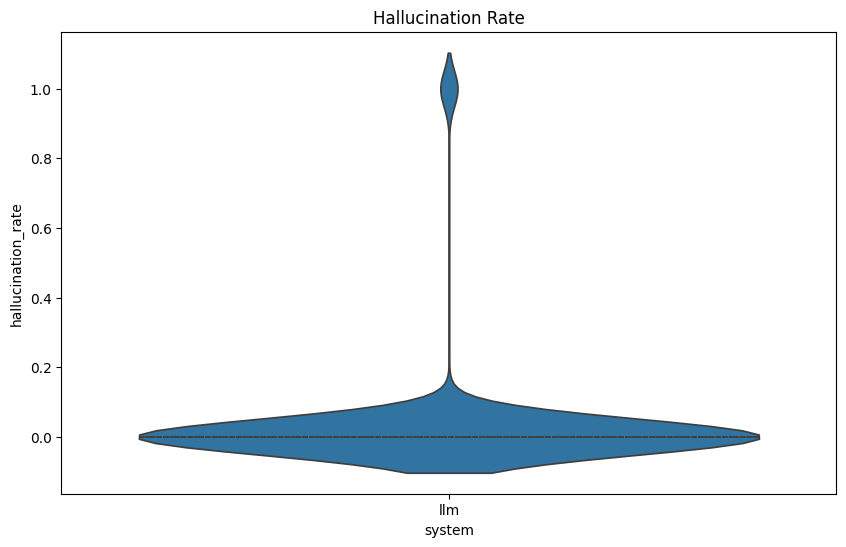

In [9]:
# Filter
plot_df = all_data[all_data["system"].isin(["llm"])]

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_df, x="system", y="hallucination_rate", inner="quartile")
plt.title("Hallucination Rate")
plt.show()